# Partie 3 : Modélisation Prédictive (XGBoost)
L'objectif de ce notebook est de construire un modèle capable de prédire si un client va se désabonner (Churn = Yes). 
Nous utiliserons l'algorithme XGBoost, réputé pour ses excellentes performances sur les données tabulaires, suivi d'une analyse SHAP pour expliquer les décisions du modèle.

### 1. Préparation des données (Preprocessing)
Les algorithmes de Machine Learning requièrent des données numériques. Nous devons transformer nos variables textuelles (catégorielles) en nombres et gérer les quelques valeurs manquantes.

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb

# Chargement des données
df = pd.read_csv('../data/telco_churn.csv')

# 1. Nettoyage basique
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna() # Suppression des 11 lignes sans TotalCharges
df = df.drop(columns=['customerID']) # L'ID ne sert à rien pour prédire

# 2. Encodage de la variable cible (Churn)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 3. Séparation des features (X) et de la cible (y)
X = df.drop(columns=['Churn'])
y = df['Churn']

# 4. Encodage des variables catégorielles (One-Hot Encoding)
# Transforme par exemple la colonne "InternetService" en "InternetService_Fiber optic", etc.
X = pd.get_dummies(X, drop_first=True)

print(f"Format des données après encodage : {X.shape}")

Format des données après encodage : (7032, 30)


### 2. Entraînement du modèle XGBoost
Nous divisons nos données : 80% pour entraîner le modèle (apprentissage) et 20% pour le tester (évaluation sur des données qu'il n'a jamais vues).

In [7]:
# Séparation Train / Test (stratify=y garantit la même proportion de churn dans les deux sets)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialisation et entraînement du modèle XGBoost
model_xgb = xgb.XGBClassifier(
    random_state=42, 
    learning_rate=0.1, 
    max_depth=4, 
    n_estimators=100
)

print("Entraînement du modèle en cours...")
model_xgb.fit(X_train, y_train)
print("Entraînement terminé.")

Entraînement du modèle en cours...
Entraînement terminé.


### 3. Évaluation des performances
Vérifions maintenant si notre modèle est capable de repérer correctement les futurs départs.

In [8]:
# Prédictions sur le set de test
y_pred = model_xgb.predict(X_test)

# Affichage des résultats
print("Rapport de classification :")
print(classification_report(y_test, y_pred))

Rapport de classification :
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.63      0.54      0.58       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407



### 4. Optimisation du modèle (Gestion du déséquilibre)
Le score de "Recall" sur la classe 1 (Churn) est de 53 %, ce qui signifie que le modèle manque presque la moitié des départs réels. 
Pour corriger cela, nous allons utiliser le paramètre `scale_pos_weight` de XGBoost, qui va pénaliser beaucoup plus lourdement l'algorithme lorsqu'il se trompe sur un client sur le point de résilier.

In [9]:
# Calcul du ratio pour rééquilibrer les poids (Nombre de classe 0 / Nombre de classe 1)
ratio = float(y_train.value_counts()[0]) / y_train.value_counts()[1]
print(f"Ratio de déséquilibre calculé : {ratio:.2f}")

# Ré-entraînement avec le paramètre scale_pos_weight
model_xgb_opt = xgb.XGBClassifier(
    random_state=42, 
    learning_rate=0.1, 
    max_depth=4, 
    n_estimators=100,
    scale_pos_weight=ratio # Le paramètre magique
)

model_xgb_opt.fit(X_train, y_train)
y_pred_opt = model_xgb_opt.predict(X_test)

print("Nouveau rapport de classification (Modèle Optimisé) :")
print(classification_report(y_test, y_pred_opt))

Ratio de déséquilibre calculé : 2.76
Nouveau rapport de classification (Modèle Optimisé) :
              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1033
           1       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.74      1407



### 5. Explicabilité du modèle (Explainable AI avec SHAP)
Un modèle performant ne suffit pas en entreprise, il faut pouvoir expliquer ses décisions aux équipes opérationnelles (Marketing, Rétention). 
Nous utilisons la librairie SHAP (SHapley Additive exPlanations) pour comprendre quelles caractéristiques (features) poussent l'algorithme à prédire un départ ou une fidélisation.

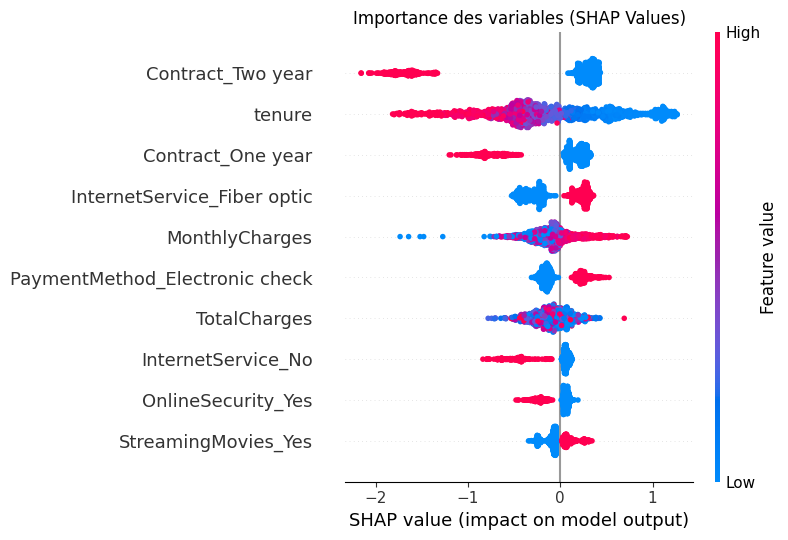

In [10]:
import shap
import matplotlib.pyplot as plt

# Initialisation de l'explainer SHAP avec notre modèle optimisé
explainer = shap.Explainer(model_xgb_opt)
shap_values = explainer(X_test)

# Génération du graphique récapitulatif (Summary Plot)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, max_display=10, show=False)
plt.title("Importance des variables (SHAP Values)")
plt.tight_layout()
plt.show()

**Interprétation du graphique SHAP :**
* L'axe vertical classe les variables par ordre d'importance (la plus importante en haut).
* L'axe horizontal montre l'impact sur la prédiction (vers la droite = pousse au Churn, vers la gauche = retient le client).
* La couleur représente la valeur de la variable (Rouge = valeur haute/Oui, Bleu = valeur basse/Non).

**Ce que le modèle a appris :**
1. **Contrat mensuel (Contract_Month-to-month) :** C'est le facteur numéro 1 de résiliation. Être sur ce contrat (points rouges à droite) fait exploser la probabilité de churn.
2. **Ancienneté (tenure) :** Une faible ancienneté (points bleus à droite) est un risque majeur. Les nouveaux clients partent le plus.
3. **Fibre Optique (InternetService_Fiber optic) :** Avoir la fibre (rouge) augmente le risque de départ, confirmant notre analyse exploratoire.
4. **Contrat de 2 ans (Contract_Two year) :** Avoir ce contrat (rouge à gauche) est le meilleur bouclier contre la résiliation.

### 6. Export des prédictions pour le Dashboard Business (Power BI)
Pour rendre notre futur tableau de bord décisionnel, nous n'allons pas seulement analyser le passé, mais aussi anticiper l'avenir. 
Nous exportons notre base de test avec la **probabilité exacte de résiliation** (Risk Score) calculée par notre modèle XGBoost pour chaque client.

In [ ]:
# On crée une copie pour ne pas toucher aux données d'origine
df_export = X_test.copy()

# On ajoute les probabilités de départ (la colonne 1 correspond à la classe 'Yes')
df_export['Risk_Score_%'] = (model_xgb_opt.predict_proba(X_test)[:, 1] * 100).round(2)

# On rajoute la vraie valeur pour comparer
df_export['Churn_Reel'] = y_test

# Sauvegarde dans un nouveau CSV pour Power BI
df_export.to_csv('../data/telco_churn_predictions.csv', index=False)
print("Fichier 'telco_churn_predictions.csv' exporté !")

Fichier 'telco_churn_predictions.csv' exporté avec succès dans le dossier data !
